<a href="https://colab.research.google.com/github/Divyansh-114/DSA-IN-C-/blob/main/MachineLearnng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from google.colab import files
uploaded = files.upload()

<Axes: xlabel='Height (cm)', ylabel='Weight (kg)'>

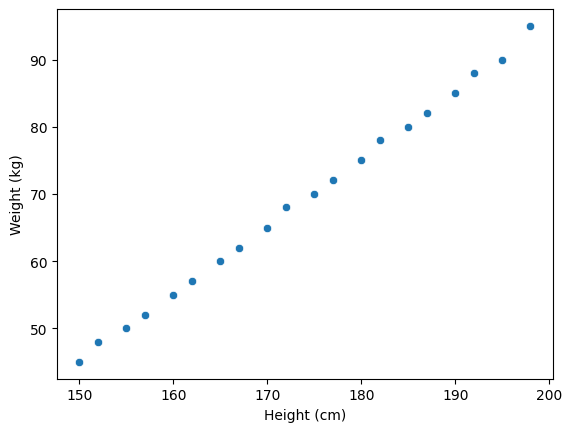

In [ ]:
sns.scatterplot(x='Height (cm)',y='Weight (kg)', data=df)

In [ ]:
df=pd.read_excel('dataset.xlsx')

In [ ]:
df.va

<Axes: xlabel='Weight (kg)', ylabel='Height (cm)'>

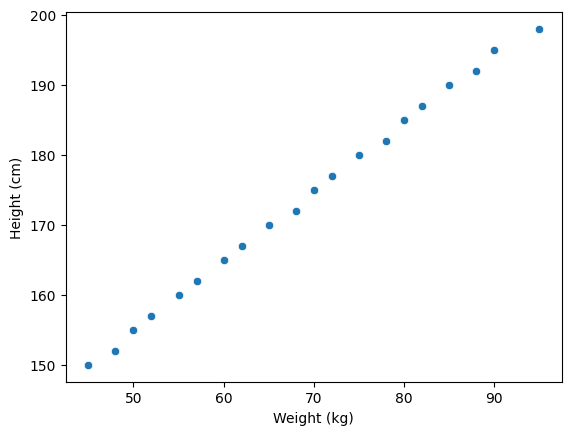

In [ ]:
sns.scatterplot(x='Weight (kg)',y='Height (cm)', data=df)

In [ ]:
## find the coorealtion between the height and weight
## by using the correlation and the covariance we concluded that they are + corelated mean
df['Height (cm)'].corr(df['Weight (kg)'])
df['Height (cm)'].cov(df['Weight (kg)'])

np.float64(223.45526315789476)

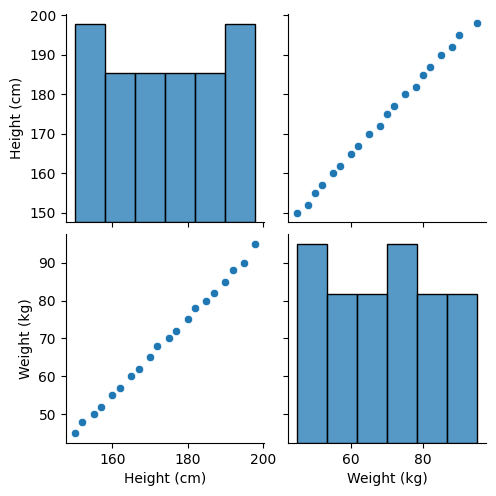

In [ ]:
sns.pairplot(df)

In [ ]:
## from the pairplot we have clearly seen that the independent and dependent feature are linearly coorealted
## so we can apply the linear regression
## Independent and Dependent Feature
X=df[['Weight (kg)']] ## independent feature should be dataframe or 2 d array
Y=df['Height (cm)'] ## dependent feature can be in one dimension because our output must be a single value
type(X)


pandas.core.frame.DataFrame

In [ ]:
Y.value_counts()

In [ ]:
type(Y)

In [ ]:
## Train Test Split
##  Here we create the training and the testing data so basically we have two column but we divided that column into four parts
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=.25,random_state = 42)

In [ ]:
## Standardization
## means we have to calculate all the value in the same unit
## we have to calculate the Z score where mean is 0 and standard deviation is 1
## Z score =(Xi-means)/Standard devaition
# from sklearn.preprocessing import StandardScaler



In [ ]:
## here by using the standarscaler we calculated the Z score
## here all the data point which we get have means 0 and std as 1
# scaler=StandardScaler()
# scaler.fit_transform(X_train)

array([[-0.95886979],
       [ 0.15322146],
       [-1.32956688],
       [ 1.48773097],
       [ 1.11703388],
       [ 0.59805796],
       [-1.47784571],
       [-0.14333621],
       [ 1.85842805],
       [-1.10714863],
       [ 0.37563971],
       [-0.58817271],
       [ 0.00494263],
       [ 0.7463368 ],
       [-0.73645154]])

In [ ]:
## we only here do the transfrom not fit_transfrom beacuse we need same mean and
## the std as we use in the train data
## DATA LEAKAGE

# X_test=scaler.transform(X_test)

In [ ]:
X_test

array([[-1.8485428 ],
       [ 1.33945213],
       [ 0.89461563],
       [-1.62612455],
       [-0.36575446]])

In [ ]:
## apply the linear regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)


In [ ]:
regression=LinearRegression(n_jobs=-1)


In [ ]:
regression.fit(X_train,Y_train)

LinearRegression(n_jobs=-1)

In [ ]:
regression.coef_

array([0.97938144])

In [ ]:
regression.intercept_

np.float64(106.17525773195875)

In [ ]:
print(" this is the slope ",regression.coef_)
print(" this is the intersept  ",regression.intercept_)

 this is the slope  [0.97938144]
 this is the intersept   106.17525773195875


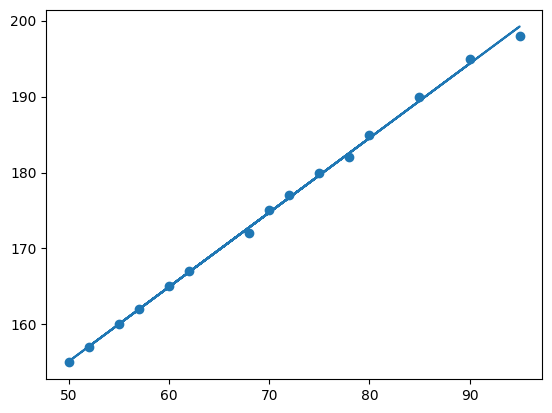

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_train,Y_train) ## this will show the given input and the output datapoints
plt.plot(X_train, regression.predict(X_train)) ## this will gives best fit line


In [ ]:
## PREDECTION
## Y = (SLOPE)X + INTERSEPT
## Y = 0.97938144(X_test) +   106.17525773195875

In [ ]:
y_predict=regression.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
## PERFORMANCE MATRIX
from sklearn.metrics import mean_absolute_error,mean_squared_error


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("MSE:", mean_squared_error(Y_test, y_pred))
print("MAE:", mean_absolute_error(Y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred)))

MSE: 4396.926069589286
MAE: 64.33938893457257
RMSE: 66.30932113654374


CALCULATE THE R SQUARE
R^2= 1-SSR/SST


In [ ]:
from sklearn.metrics import r2_score
r2_score(Y_test,y_predict)

-13.687754107393395

In [ ]:
## OLS LINAER REGRESSION
import statsmodels.api as sm

In [ ]:
model=sm.OLS(Y_train,X_train).fit()

In [ ]:
model.predict(X_train)

,0
5,139.260419
11,175.907897
3,127.044593
18,219.884872
16,207.669045
13,190.566889
2,122.158262
9,166.135236
19,232.100698
4,134.374088


In [ ]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            Height (cm)   R-squared (uncentered):                   0.987
Model:                            OLS   Adj. R-squared (uncentered):              0.986
Method:                 Least Squares   F-statistic:                              1048.
Date:                Sat, 28 Feb 2026   Prob (F-statistic):                    1.46e-14
Time:                        09:29:09   Log-Likelihood:                         -66.305
No. Observations:                  15   AIC:                                      134.6
Df Residuals:                      14   BIC:                                      135.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [ ]:
## prediction for new data
height=regression.predict([[60]])
print(" For the given WEIGHT the HEIGHT is ",float(height),"cm")

 For the given WEIGHT the HEIGHT is  164.9381443298969 cm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipython-input-424/2764755249.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(" For the given WEIGHT the HEIGHT is ",float(height),"cm")


# New section